# Exploration strategies for DQN algorithm

In this assignment we are interested in exploration strategies that can be combined with Q-learning.
Q-learning is an off-policy algorithm, which means that the data for the algorithm can be collected by a different policy (called behavioural policy) that the one the algorithm learns.

Here we come across a classical trade-off in reinforcement learning, called exploration-exploitation trade-off. On the one hand, our behavioural policy should try out new state-action pairs to gain knowledge about their returns. On the other hand, when our estimate of returns is good enough, we would like to follow the state-action pairs with the highest estimated returns.

We will be operating on DQN [(Mnih 2014)](https://www.cs.toronto.edu/~vmnih/docs/dqn.pdf) algorithm and analyzing epsilon-greedy strategy, boltzmann and max-boltzmann strategy and combination of epsilon-greedy and boltzmann.
We evaluate performance of DQN variants on the Lunar Lander environment.

We provide an implementation of the DQN algorithm with random exploration strategy.
Your goal is to implement the exploration variants by overriding appropriate methods of the provided class.


## Grading

To obtain the points for the assignment You need to provide the implementation of exploration techniques AND report with plots and conclusions.
Measuring sensitivity means that You should at least examine one reasonably lower and one reasonably greater value of the considered hyperparameter (or the pair of hyperparameters).


1. Implement epsilon-greedy strategy and investigate hyperparameter sensitivity (1 point).
2. Implement epsilon-greedy strategy with epsilon annealing and investigate hyperparameter sensitivity (1 point).
3. Implement boltzmann strategy and investigate hyperparameter sensitivity (1 point).
4. Implement boltzmann strategy with temperature annealing and investigate hyperparameter sensitivity (1 point).
5. Implement max-boltzmann strategy and investigate hyperparameter sensitivity (1 point).
6. Implement max-boltzmann strategy with temperature annealing and investigate hyperparameter sensitivity (1 point).
7. Implement combination of epsilon-greedy with epsilon annealing and boltzmann strategy and investigate hyperparameter sensitivity (1 point)
8. (*) Bonus: propose another reasonable approach to combine epsilon-greedy with epsilon annealing strategy and boltzmann strategy and/or another reasonable strategy of temperature annealing for the boltzmann strategy (2 points).
9. Compare methods, present plots and conclusions in a clear manner (3 points).

You can obtain max 10 points, bonus points increase Your score, if You lose points in some other tasks.

Here we import necessary libraries.

In [1]:
!apt-get install swig
!pip install gymnasium[box2d]

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 1s (800 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu

In [2]:
import torch
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

Here we set hyperparameters of the training, set seeds for reproducibility and set weights initialization.
Although for debugging it might be useful to operate on a smaller number of training_steps, seeds etc., in the final evaluation DO NOT CHANGE these parameters.

In [3]:
class parse_args:
  def __init__(self):
    self.n_seeds = 6
    self.n_evaluate_episodes = 5
    self.n_training_steps = 100000
    self.buffer_size = 10000
    self.init_steps = 10000
    self.target_update_freq = 50
    self.eval_freq = 1000
    self.gym_id = "LunarLander-v3"
    env = gym.make(self.gym_id)
    self.state_dim = env.observation_space.shape[0]
    self.batch_size = 128
    self.hidden_dim = 128
    self.action_dim = env.action_space.n
    self.discount = 0.99
    self.lr = 7e-4
    self.cuda = True
    self.device = torch.device("cuda" if torch.cuda.is_available() and self.cuda else "cpu")

args = parse_args()
first_half_training_args = parse_args()
first_half_training_args.n_training_steps = first_half_training_args.n_training_steps // 2
second_half_training_args = parse_args()
second_half_training_args.n_training_steps = second_half_training_args.n_training_steps // 2
second_half_training_args.init_steps = 1

In [4]:
def set_seed(seed):
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)

def weight_init(model):
  torch.nn.init.orthogonal_(model.weight.data)
  model.bias.data.fill_(0.0)

Here we implement the replay buffer.
It has two methods: add one transition to the buffer and sample batch of transitions from the buffer.

In [5]:
class ReplayBuffer:
  def __init__(self, args):
    self.states = np.zeros((args.buffer_size, args.n_seeds, args.state_dim), dtype = np.float32)
    self.actions = np.zeros((args.buffer_size, args.n_seeds), dtype = np.int64)
    self.rewards = np.zeros((args.buffer_size, args.n_seeds), dtype = np.float32)
    self.next_states = np.zeros((args.buffer_size, args.n_seeds, args.state_dim), dtype = np.float32)
    self.terminals = np.zeros((args.buffer_size, args.n_seeds), dtype = np.int64)
    self.idx = 0
    self.current_size = 0
    self.args = args

  def add(self, state, action, reward, next_state, terminal):
    if self.current_size < self.args.buffer_size:
      self.current_size += 1
    self.states[self.idx, :, :] = state
    self.actions[self.idx, :] = action
    self.rewards[self.idx, :] = reward
    self.next_states[self.idx, :, :] = next_state
    self.terminals[self.idx, :] = terminal
    self.idx = (self.idx + 1) % self.args.buffer_size

  def sample(self):
    sample_idxs = np.random.permutation(self.current_size)[:self.args.batch_size]
    states = torch.from_numpy(self.states[sample_idxs]).to(self.args.device)
    actions = torch.from_numpy(self.actions[sample_idxs]).to(self.args.device)
    rewards = torch.from_numpy(self.rewards[sample_idxs]).to(self.args.device)
    next_states = torch.from_numpy(self.next_states[sample_idxs]).to(self.args.device)
    terminals = torch.from_numpy(self.terminals[sample_idxs]).to(self.args.device)

    return states, actions, rewards, next_states, terminals


Here we implement a simple Q network architecture with three layers and ReLU activations.

In [6]:
class QNetwork(torch.nn.Module):
  def __init__(self, args):
    super(QNetwork, self).__init__()
    self.layer_1 = torch.nn.Linear(args.state_dim, args.hidden_dim)
    self.layer_2 = torch.nn.Linear(args.hidden_dim, args.hidden_dim)
    self.layer_3 = torch.nn.Linear(args.hidden_dim, args.action_dim)
    self.relu = torch.nn.ReLU()

    self.layer_1.apply(weight_init)
    self.layer_2.apply(weight_init)
    self.layer_3.apply(weight_init)

  def forward(self, x):
    x = self.relu(self.layer_1(x))
    x = self.relu(self.layer_2(x))
    x = self.layer_3(x)

    return x

Here we provide code for DQN with random exploration.

In [7]:
TRAIN_SEED = 0
EVAL_SEED = 1

class DQN:
  def __init__(self, args):
    self.args = args
    self.discount = self.args.discount
    self.reset()
    self.annealing = False

  # Copying parameters of other DQN class by reference (for half epsion-greedy, half boltzmann task)
  def copy_reference(self, other):
    self.buffer = other.buffer
    self.q_net = other.q_net
    self.q_target = other.q_target
    self.optimizer = other.optimizer

  # Annealing of epsilon and/or temperature
  def anneal(self, step):
    pass

  # Greedy action
  def get_greedy_action(self, states):
    with torch.no_grad():
      action = torch.argmax(self.q_net(states), dim = -1).detach().cpu().numpy()
      return action

  # Exploration action choice
  def explore(self, states):
    # Random action choice
    action = np.random.randint(self.args.action_dim, size = self.args.n_seeds)
    return action

  # Update of the main critic
  def update(self):
    states, actions, rewards, next_states, terminals = self.buffer.sample()
    with torch.no_grad():
      q_next_states = torch.max(self.q_target(next_states), dim = -1)[0]
    ones_tensor = torch.ones_like(terminals).to(self.args.device)
    targets = rewards + (ones_tensor - terminals) * self.discount * q_next_states

    self.optimizer.zero_grad()
    q_values = self.q_net(states).gather(-1, actions.unsqueeze(-1)).squeeze(-1)
    loss = torch.mean((q_values - targets) ** 2)
    loss.backward()
    self.optimizer.step()

  # Update of the targer critic
  def update_target(self):
    self.q_target.load_state_dict(self.q_net.state_dict())

  # Evaluation of the performance on test environments.
  def evaluate(self):
    eval_results = np.zeros(self.args.n_seeds)
    with torch.no_grad():
      eval_env = gym.make_vec(self.args.gym_id, num_envs = self.args.n_seeds, vectorization_mode="sync")
      eval_env.reset(seed = EVAL_SEED)
      for _ in range(self.args.n_evaluate_episodes):
        state, info = eval_env.reset()
        episode_reward = np.zeros(self.args.n_seeds)
        mask = np.ones(self.args.n_seeds)
        while np.sum(mask) > 0:
          action = self.get_greedy_action(torch.tensor(state).to(self.args.device))
          next_state, reward, terminal, truncated, _ = eval_env.step(action)
          episode_reward += mask * reward
          state = next_state
          mask *= (np.ones(self.args.n_seeds) - terminal) * (np.ones(self.args.n_seeds) - truncated)
        eval_results += episode_reward / self.args.n_evaluate_episodes
    return np.mean(eval_results), np.std(eval_results)


  # Resetting the algorithm
  def reset(self):
    self.buffer = ReplayBuffer(self.args)
    self.q_net = QNetwork(self.args).to(self.args.device) # main critic
    self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr = self.args.lr, eps = 1e-5)
    self.q_target = QNetwork(self.args).to(self.args.device) # target critic
    self.update_target()

  # Training loop
  def train(self):
    eval_results_means = np.array([])
    eval_results_stds = np.array([])
    train_env = gym.make_vec(self.args.gym_id, num_envs = self.args.n_seeds, vectorization_mode="sync")
    state, info = train_env.reset(seed = TRAIN_SEED)
    mask = np.ones(self.args.n_seeds)
    for step in range(self.args.n_training_steps):
      action = self.explore(torch.tensor(state).unsqueeze(0).to(self.args.device))
      if self.annealing:
        self.anneal(step)
      next_state, reward, terminal, truncated, _ = train_env.step(action)
      self.buffer.add(state, action, reward, next_state, terminal)
      state = next_state
      if step % self.args.eval_freq == 0:
          print(f"Training step: {step}")
          eval_mean, eval_std = self.evaluate()
          print(f"Eval mean: {eval_mean}; eval_std: {eval_std}")
          eval_results_means = np.append(eval_results_means, eval_mean)
          eval_results_stds = np.append(eval_results_stds, eval_std)
      if step >= self.args.init_steps:
        self.update()
        if step % self.args.target_update_freq == 0:
          self.update_target()
      mask *= (np.ones(self.args.n_seeds) - terminal) * (np.ones(self.args.n_seeds) - truncated)
      if np.sum(mask) == 0:
        state, info = train_env.reset()
        mask = np.ones(self.args.n_seeds)

    return eval_results_means, eval_results_stds


Here we implement functions for plotting.

In [8]:
def smooth(data, weigth = 0.9):
  smooth_data = np.copy(data)
  for index in range(1, len(data)):
    smooth_data[index] = smooth_data[index - 1] * weigth + data[index] * (1.0 - weigth)

  return smooth_data

def plot_smooth(args, result_means, result_stds):
  smooth_result_means = smooth(result_means)
  smooth_result_stds = smooth(result_stds)
  print(smooth_result_means)
  print(smooth_result_stds)
  xs = np.arange(len(result_means)) * args.eval_freq
  print(xs)
  plt.plot(xs, smooth_result_means, color = "blue")
  plt.fill_between(xs, smooth_result_means - smooth_result_stds, smooth_result_means + smooth_result_stds, alpha = 0.2, label = "smoothed_rewards")
  plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
  plt.show()
  plt.clf()

def plot_smooth_many(args, result_means_list, result_stds_list, names_list, colours_list):
  plt.figure(figsize=(12.8, 9.6))
  for result_means, result_stds, name, colour in zip(result_means_list, result_stds_list, names_list, colours_list):
    smooth_result_means = smooth(result_means)
    smooth_result_stds = smooth(result_stds)
    print(smooth_result_means)
    print(smooth_result_stds)
    xs = np.arange(len(result_means)) * args.eval_freq
    print(xs)
    plt.plot(xs, smooth_result_means, color = colour)
    plt.fill_between(xs, smooth_result_means - smooth_result_stds, smooth_result_means + smooth_result_stds, alpha = 0.2, color = colour, label = f"smoothed_rewards_{name}")
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
  plt.show()
  plt.clf()

def plot_results(result_mean, result_std):
  plot_smooth(args, result_mean, result_std)

def plot_results_many(result_means_list, result_stds_list, name_list, colours_list):
  plot_smooth_many(args, result_means_list, result_stds_list, name_list, colours_list)

Here we provide code for training across different random seeds.

In [9]:
def train_dqn(dqn):
  set_seed(TRAIN_SEED)
  dqn.reset()
  result_mean, result_std = dqn.train()
  print(result_mean)
  return result_mean, result_std


Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -91.47844743831462; eval_std: 8.630728694108207
Training step: 12000
Eval mean: -132.55935990054934; 

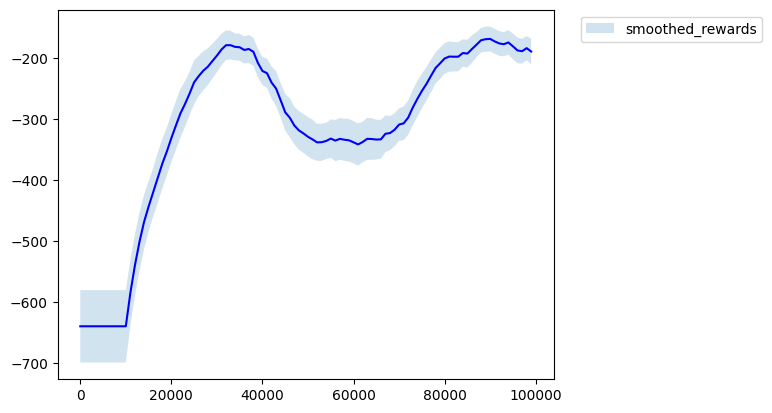

<Figure size 640x480 with 0 Axes>

In [29]:
dqn = DQN(args)
result_means_dqn, result_stds_dqn = train_dqn(dqn)
plot_results(result_means_dqn, result_stds_dqn)

Here the goal is to implement the epsilon-gredy strategy. With probability epsilon we choose uniformly a random action and with probability 1-epsilon we take the action with the highest Q-value according to the main critic.

In [11]:
class EpsilonGreedyDQN(DQN):
  def __init__(self, args):
    super(EpsilonGreedyDQN, self).__init__(args)
    self.epsilon = 0.1 # investigate sensitivity

  def explore(self, states):
    action = None
    # TODO
    ####################################
    action = np.empty(self.args.n_seeds, dtype=np.int64)

    greedy_actions = self.get_greedy_action(states).squeeze(0)
    random_mask = np.random.rand(self.args.n_seeds) < self.epsilon

    action[random_mask] = np.random.randint(self.args.action_dim, size=np.sum(random_mask))
    action[~random_mask] = greedy_actions[~random_mask]
    ####################################
    return action

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -27.62291207489302; eval_std: 35.47085230055382
Training step: 12000
Eval mean: -33.380681566551644; 

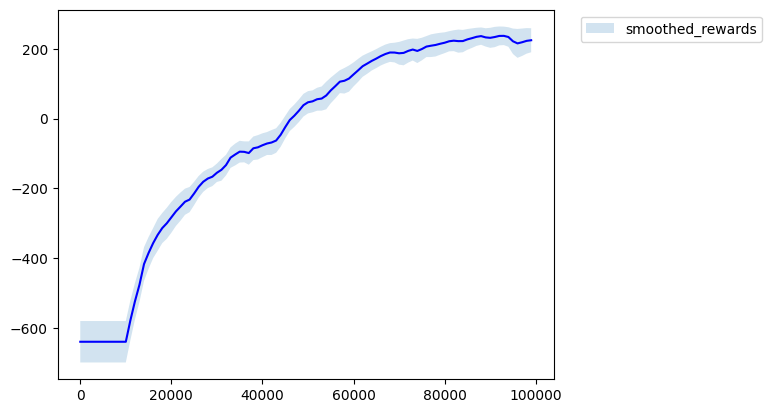

<Figure size 640x480 with 0 Axes>

In [12]:
epsilon_greedy_dqn = EpsilonGreedyDQN(args)
result_means_epsilon_greedy_dqn, result_stds_epsilon_greedy_dqn = train_dqn(epsilon_greedy_dqn)
plot_results(result_means_epsilon_greedy_dqn, result_stds_epsilon_greedy_dqn)

Here we add to the epsilon-greedy strategy epsilon annealing. We change linearly epsilon from 1.0 to the value final_epsilon during first anneal_steps steps and then it remains on the final_epsilon level.
Such an approach aims to increase the exploration level at the beginning of the training, when the Q-value estimate is poor and thus choosing greedily according to Q is not improving the performance.

In [13]:
class EpsilonGreedyWithAnnealingDQN(EpsilonGreedyDQN):
  def __init__(self, args):
    self.start_epsilon = 1.0
    super(EpsilonGreedyWithAnnealingDQN, self).__init__(args)
    self.epsilon = self.start_epsilon
    self.final_epsilon = 0.1 # investigate sensitivity
    self.annealing = True
    self.anneal_steps = 30000

  def anneal(self, step):
    # TODO
    ####################################
    if step >= self.anneal_steps:
      self.epsilon = self.final_epsilon
    else:
      self.epsilon = self.start_epsilon - (self.start_epsilon - self.final_epsilon) * step / self.anneal_steps
    ####################################

  def reset(self):
    super(EpsilonGreedyWithAnnealingDQN, self).reset()
    self.epsilon = self.start_epsilon

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -125.62323367748047; eval_std: 9.1603644908525
Training step: 12000
Eval mean: -80.06262885753317; ev

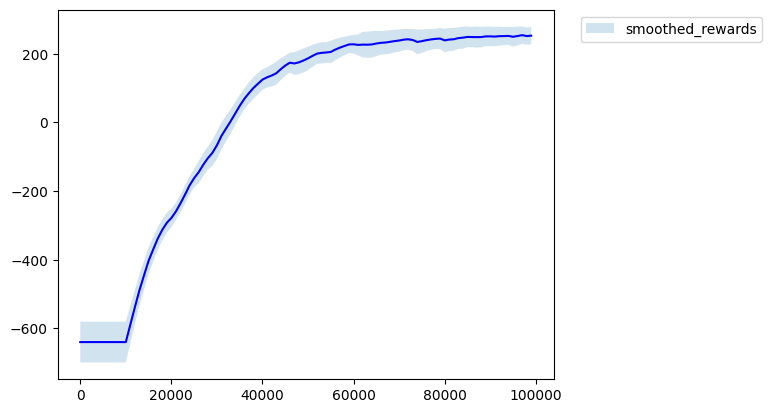

<Figure size 640x480 with 0 Axes>

In [14]:
epsilon_greedy_with_annealing_dqn = EpsilonGreedyWithAnnealingDQN(args)
result_means_epsilon_greedy_with_annealing_dqn, result_stds_epsilon_greedy_with_annealing_dqn = train_dqn(epsilon_greedy_with_annealing_dqn)
plot_results(result_means_epsilon_greedy_with_annealing_dqn, result_stds_epsilon_greedy_with_annealing_dqn)

Alternative approach to the epsilon-greedy strategy is to use so-called boltzmann exploration strategy.
The idea behind this approach is to perform softmax on the Q-values coming from the main critic and then sample from the obtained distribution.
In this approach we use softmax with a temperature, i.e. before applying softmax, we scale all the Q-values by the temperature coefficient (in the literature we usually divide by the temperature, but this is equivallent to scaling by the inverse of the temperature). Large scaling values make the distribution close to the greedy choice, while low scaling values make the distribution close to the uniform one.

In [17]:
class BoltzmannDQN(DQN):
  def __init__(self, args):
    super(BoltzmannDQN, self).__init__(args)
    self.temperature = 1.0 # investigate sensitivity

  def explore(self, states):
    action = None
    with torch.no_grad():
      # TODO
      ####################################
      q_values = self.q_net(states).squeeze(0)
      scaled_q = q_values * self.temperature

      probs = torch.softmax(scaled_q, dim=-1)

      action = torch.multinomial(probs, num_samples=1).squeeze(-1).cpu().numpy()
      ####################################

    return action

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -160.38766232174882; eval_std: 54.90928905390768
Training step: 12000
Eval mean: -71.45181750951582; 

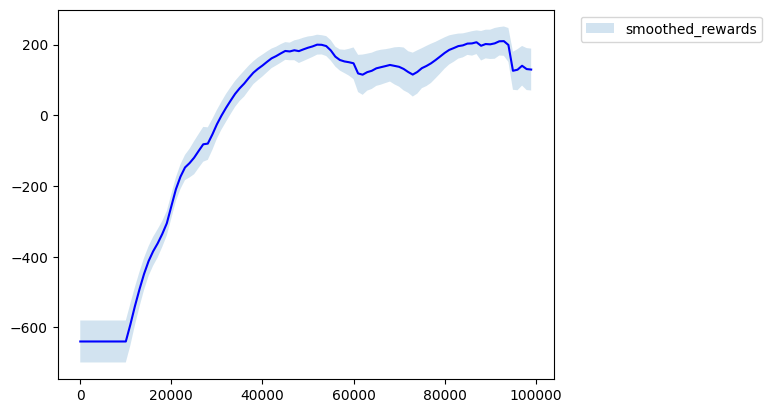

<Figure size 640x480 with 0 Axes>

In [18]:
boltzmann_dqn = BoltzmannDQN(args)
result_means_boltzmann_dqn, result_stds_boltzmann_dqn = train_dqn(boltzmann_dqn)
plot_results(result_means_boltzmann_dqn, result_stds_boltzmann_dqn)

One of the compromises between epsilon-greedy and boltzmann exploration strategy is so-calles max-boltzmann strategy. In this strategy with probability 1-epsilon we choose action greedily, but with probability epsilon we perform the boltzmann choice instead of the uniform random choice.

In [19]:
class MaxBoltzmannDQN(EpsilonGreedyWithAnnealingDQN):
  def __init__(self, args):
    super(MaxBoltzmannDQN, self).__init__(args)
    self.temperature = 0.1 # investigate sensitivity

  def explore(self, states):
    action = None
    with torch.no_grad():
      # TODO
      ####################################
      greedy_actions = self.get_greedy_action(states).squeeze(0)

      q_values = self.q_net(states).squeeze(0)
      scaled_q = q_values * self.temperature
      probs = torch.softmax(scaled_q, dim=-1)

      boltzmann_actions = torch.multinomial(probs, num_samples=1).squeeze(-1).cpu().numpy()

      random_mask = np.random.rand(self.args.n_seeds) < self.epsilon
      action = np.where(random_mask, boltzmann_actions, greedy_actions)
      ####################################
    return action

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -94.24552936364675; eval_std: 7.6973832004845875
Training step: 12000
Eval mean: -51.77180383041301; 

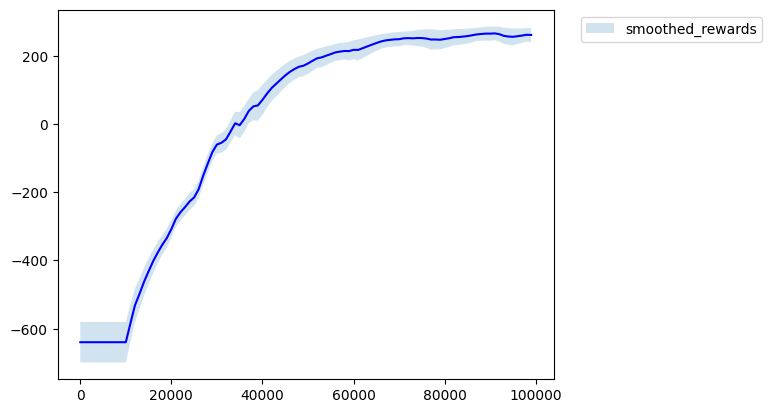

<Figure size 640x480 with 0 Axes>

In [20]:
max_boltzmann_dqn = MaxBoltzmannDQN(args)
result_means_max_boltzmann_dqn, result_stds_max_boltzmann_dqn = train_dqn(max_boltzmann_dqn)
plot_results(result_means_max_boltzmann_dqn, result_stds_max_boltzmann_dqn)

Similarly to adjusting the value of epsilon in epsilon-greedy strategy, we can adjust the temperature in the max-boltzmann and boltzmann strategies: we start we the value start_temperature and linearly increase the value to the final_temperature during temperature_anneal_steps, then the temperature is on the constant level.


In [21]:
class MaxBoltzmannWithTemperatureAnnealingDQN(MaxBoltzmannDQN):
  def __init__(self, args):
    self.start_temperature = 0.025 # investigate sensitivity
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temperature
    self.final_temperature = 0.3 # investigate sensitivity
    self.temperature_anneal_steps = 30000
    self.annealing = True

  def anneal(self, step):
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).anneal(step)
    # TODO
    ####################################
    if step >= self.temperature_anneal_steps:
      self.temperature = self.final_temperature
    else:
      self.temperature = self.start_temperature + (self.final_temperature - self.start_temperature) * step / self.temperature_anneal_steps
    ####################################

  def reset(self):
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).reset()
    self.temperature = self.start_temperature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -103.89833022589421; eval_std: 8.24019678059071
Training step: 12000
Eval mean: -97.66268410660145; e

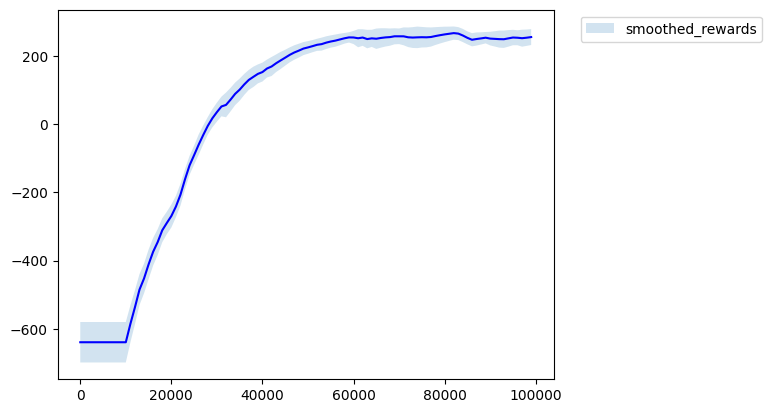

<Figure size 640x480 with 0 Axes>

In [22]:
max_boltzmann_temp_anneal_dqn = MaxBoltzmannWithTemperatureAnnealingDQN(args)
result_means_max_boltzmann_temp_anneal_dqn, result_stds_max_boltzmann_temp_anneal_dqn = train_dqn(max_boltzmann_temp_anneal_dqn)
plot_results(result_means_max_boltzmann_temp_anneal_dqn, result_stds_max_boltzmann_temp_anneal_dqn)

In [23]:
class BoltzmannWithTemperatureAnnealingDQN(BoltzmannDQN):
  def __init__(self, args):
    self.start_temperature = 0.25 # investigate sensitivity
    super(BoltzmannWithTemperatureAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temperature
    self.final_temperature = 3.0 # investigate sensitivity
    self.temperature_anneal_steps = 30000
    self.annealing = True

  def anneal(self, step):
    # TODO
    ####################################
    if step >= self.temperature_anneal_steps:
      self.temperature = self.final_temperature
    else:
      self.temperature = self.start_temperature + (self.final_temperature - self.start_temperature) * step / self.temperature_anneal_steps
    ####################################

  def reset(self):
    super(BoltzmannWithTemperatureAnnealingDQN, self).reset()
    self.temperature = self.start_temperature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -102.55505897341702; eval_std: 10.912025691747884
Training step: 12000
Eval mean: -107.17483206376146

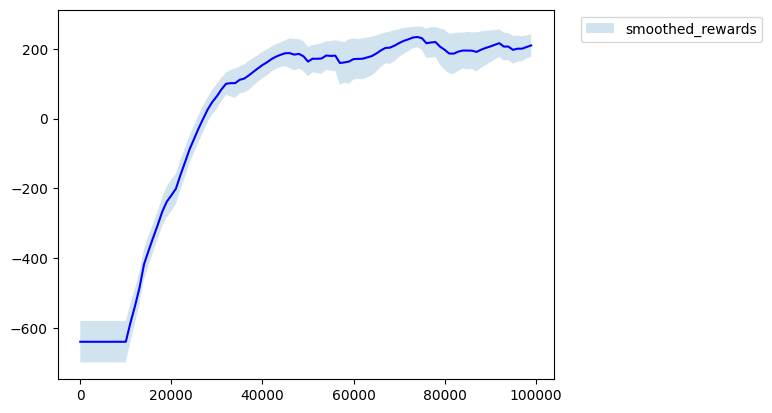

<Figure size 640x480 with 0 Axes>

In [24]:
boltzmann_temp_anneal_dqn = BoltzmannWithTemperatureAnnealingDQN(args)
result_means_boltzmann_temp_anneal_dqn, result_stds_boltzmann_temp_anneal_dqn = train_dqn(boltzmann_temp_anneal_dqn)
plot_results(result_means_boltzmann_temp_anneal_dqn, result_stds_boltzmann_temp_anneal_dqn)

The last exploration idea we want to implement is a combintation of the epsilon-greedy strategy (with epsilon annealing) and the boltzmann strategy.
We could think that at the beginning of the training the boltzmann strategy struggles because the Q-function (the main critic) is not yet well-trained. However, the more critic is trained, the more sense it makes to start using the boltzmann strategy. We would like to verify this hypoothesis by using in the first half of the training epsilon-greedy strategy (with epsilon annealing) and in the second half of the training switch the exploration strategy to the boltzmann one.

In [25]:
def train_two_halfs_dqn(dqn_1, dqn_2):
  set_seed(TRAIN_SEED)
  # TODO
  ####################################
  dqn_1.reset()
  result_mean1, result_std1 = dqn_1.train()

  dqn_2.copy_reference(dqn_1)
  result_mean2, result_std2 = dqn_2.train()

  result_mean = np.concatenate([result_mean1, result_mean2])
  result_std = np.concatenate([result_std1, result_std2])
  ####################################

  return result_mean, result_std


Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -125.62323367748047; eval_std: 9.1603644908525
Training step: 12000
Eval mean: -80.06262885753317; ev

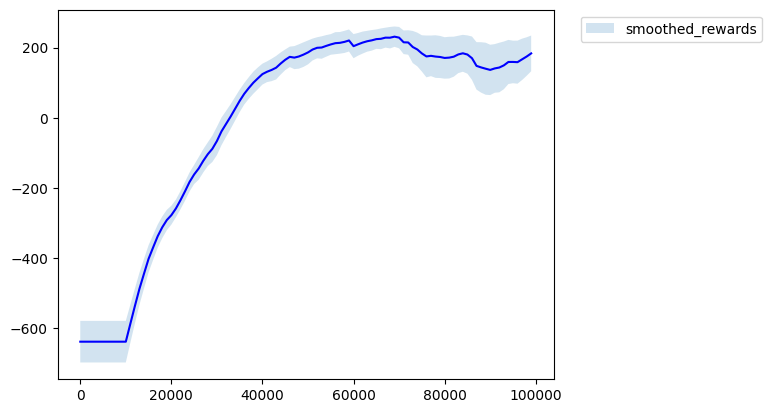

<Figure size 640x480 with 0 Axes>

In [27]:
epsilon_greedy_with_annealing_half_dqn = EpsilonGreedyWithAnnealingDQN(first_half_training_args) # investigate sensitivity of epsilon
epsilon_greedy_boltzmann_half_dqn = BoltzmannDQN(second_half_training_args) # investigate sensitivity of temperature
result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn = train_two_halfs_dqn(epsilon_greedy_with_annealing_half_dqn, epsilon_greedy_boltzmann_half_dqn)
plot_results(result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn)

Here we plot the results of all exploration methods on one plot. However, for drawing conclusions, it might be reasonable to plot some subsets of methods together, for example to compare variants with and without annealing, max-boltzmann with boltzmann, epsilon-greedy, boltzmann and half-epsilon-greedy, half-boltzmann.

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -584.86915772 -539.63817794 -501.16492719 -468.66523335
 -443.30481401 -419.97181763 -396.55983807 -373.10648845 -353.12273969
 -330.9704732  -310.26922999 -290.29622055 -274.90753534 -257.85877908
 -239.33726274 -229.26164893 -220.44524702 -213.88189325 -204.68977095
 -195.68415207 -185.66145431 -178.53817546 -178.55217742 -181.28219648
 -181.91826216 -186.3149428  -184.78374514 -189.21718109 -207.63906164
 -220.85687297 -224.4681434  -239.83748443 -249.76261159 -268.98485944
 -288.62733088 -297.46937802 -310.30981937 -318.28398609 -323.25721242
 -328.78818001 -333.11047078 -337.97171862 -337.67793447 -335.61180913
 -331.69657148 -335.04789674 -332.19471906 -333.61816849 -334.5660527
 -337.85432601 -341.34043409 -337.35500406 -332.13215232 -332.48400575
 -333.29902883 -333.02196673 -323.82951765 -322.73330894 -317.32223231
 -308.7

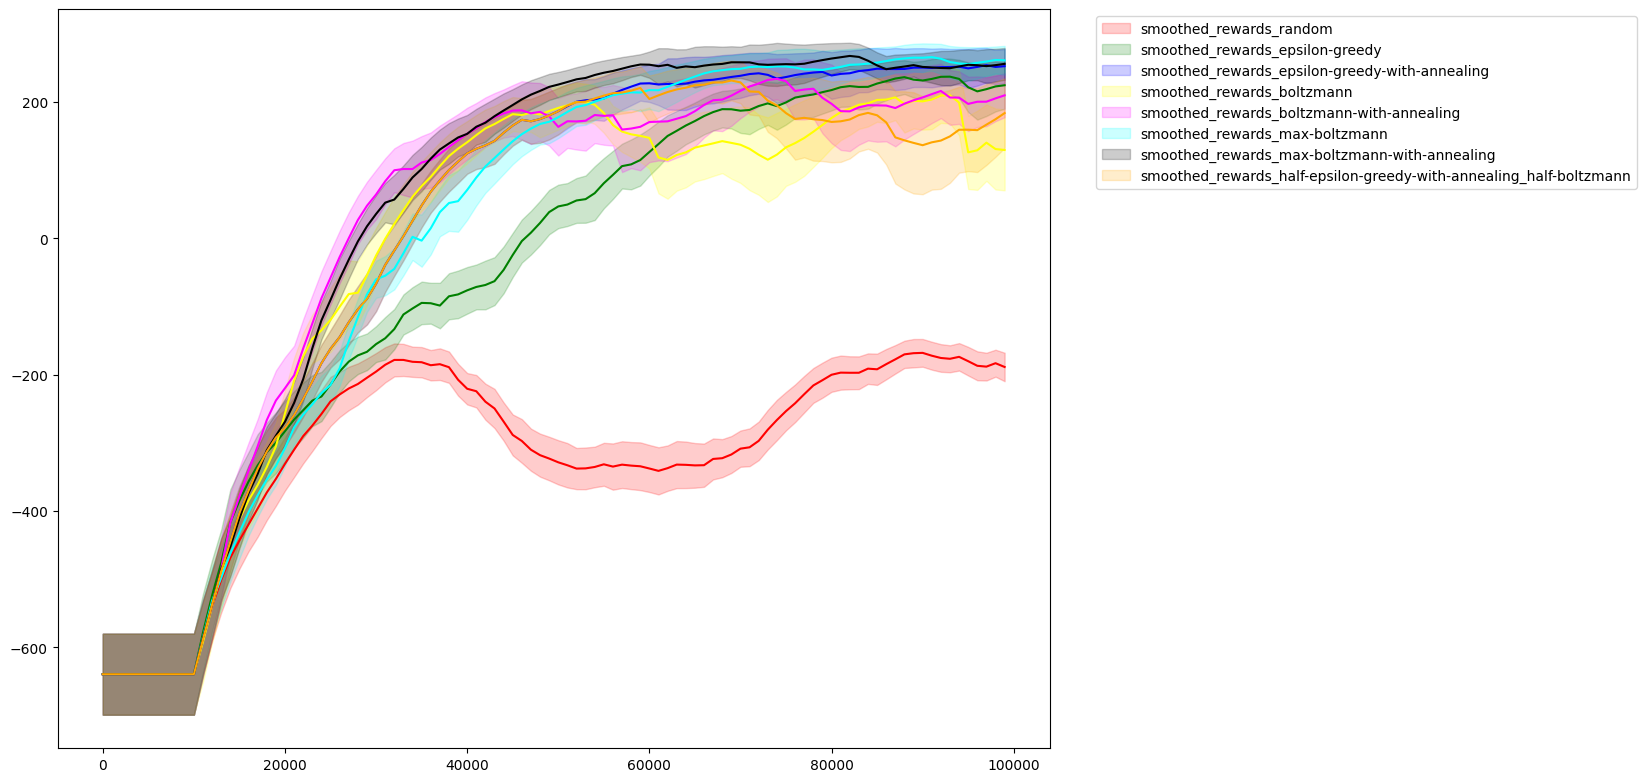

<Figure size 640x480 with 0 Axes>

In [30]:
result_means_list = [result_means_dqn, result_means_epsilon_greedy_dqn, result_means_epsilon_greedy_with_annealing_dqn,
                result_means_boltzmann_dqn, result_means_boltzmann_temp_anneal_dqn,
                result_means_max_boltzmann_dqn, result_means_max_boltzmann_temp_anneal_dqn,
                result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
result_stds_list = [result_stds_dqn, result_stds_epsilon_greedy_dqn, result_stds_epsilon_greedy_with_annealing_dqn,
                result_stds_boltzmann_dqn, result_stds_boltzmann_temp_anneal_dqn,
                result_stds_max_boltzmann_dqn, result_stds_max_boltzmann_temp_anneal_dqn,
                result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
names_list = ["random", "epsilon-greedy", "epsilon-greedy-with-annealing",
             "boltzmann", "boltzmann-with-annealing",
             "max-boltzmann", "max-boltzmann-with-annealing",
             "half-epsilon-greedy-with-annealing_half-boltzmann"]
colours_list = ["red", "green", "blue",
           "yellow", "magenta",
           "cyan", "black",
           "orange"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)

## Measuring Sensitivity
Here we investigate hyperparameter sensitivity for each implemented strategy.

In [15]:
colours_list = ["red", "green", "blue"]

### Epsilon-Greedy Strategy

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -110.62390472899801; eval_std: 8.900343957428149
Training step: 12000
Eval mean: 36.44826414224904; e

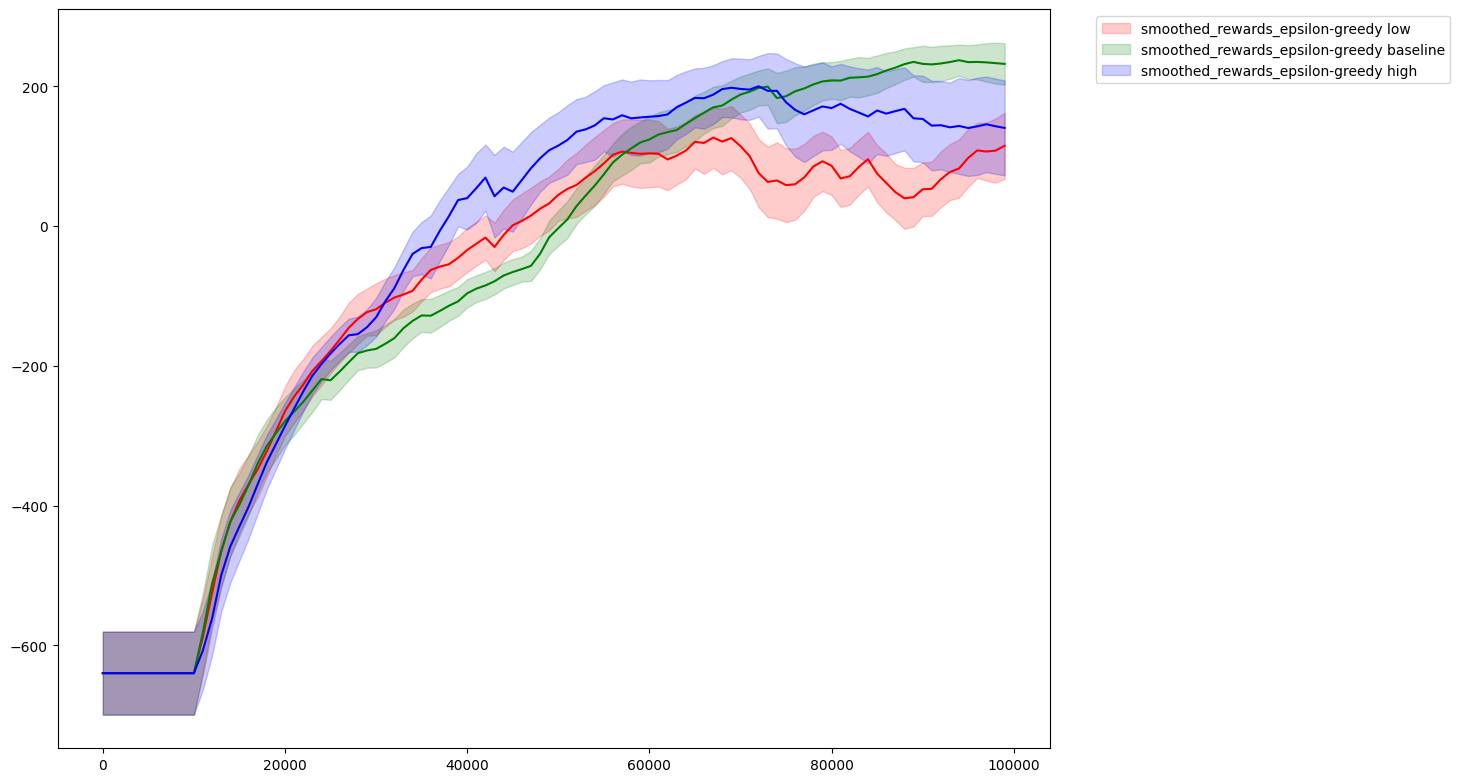

<Figure size 640x480 with 0 Axes>

In [27]:
eps_greedy_low = EpsilonGreedyDQN(args)
eps_greedy_low.epsilon = 0.05
eps_greedy_low_mean, eps_greedy_low_std = train_dqn(eps_greedy_low)

eps_greedy_high = EpsilonGreedyDQN(args)
eps_greedy_high.epsilon = 0.3
eps_greedy_high_mean, eps_greedy_high_std = train_dqn(eps_greedy_high)

plot_results_many(
    [eps_greedy_low_mean, result_means_epsilon_greedy_dqn, eps_greedy_high_mean],
    [eps_greedy_low_std, result_stds_epsilon_greedy_dqn, eps_greedy_high_std],
    ["epsilon-greedy low", "epsilon-greedy baseline", "epsilon-greedy high"],
    colours_list
)

### Epsilon-Greedy Strategy with Epsilon Annealing

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -77.88925625586852; eval_std: 7.659094362994459
Training step: 12000
Eval mean: -74.50048603573156; e

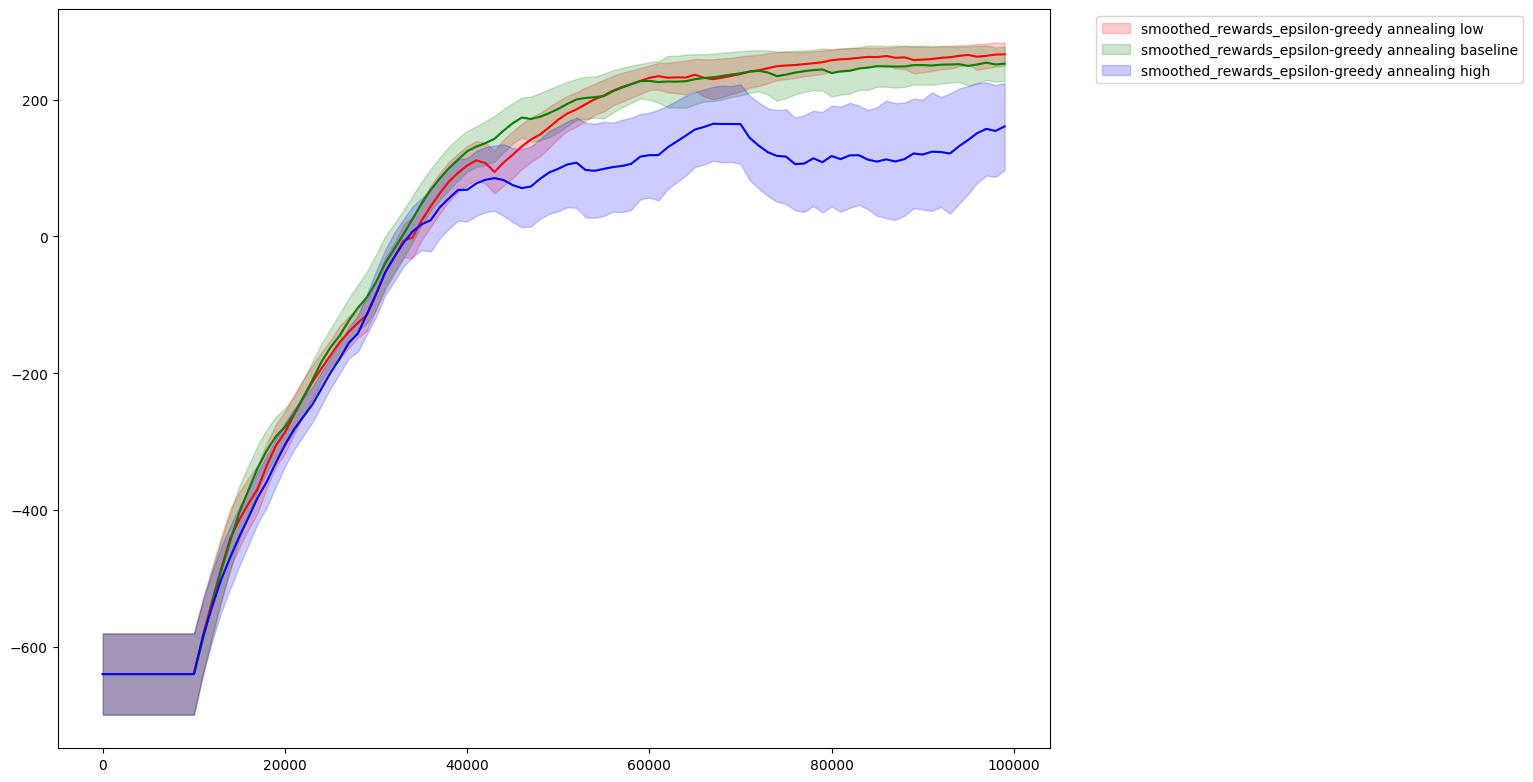

<Figure size 640x480 with 0 Axes>

In [16]:
eps_greedy_annealing_low = EpsilonGreedyWithAnnealingDQN(args)
eps_greedy_annealing_low.final_epsilon = 0.025
eps_greedy_annealing_low_mean, eps_greedy_annealing_low_std = train_dqn(eps_greedy_annealing_low)

eps_greedy_annealing_high = EpsilonGreedyWithAnnealingDQN(args)
eps_greedy_annealing_high.final_epsilon = 0.4
eps_greedy_annealing_high_mean, eps_greedy_annealing_high_std = train_dqn(eps_greedy_annealing_high)

plot_results_many(
    [eps_greedy_annealing_low_mean, result_means_epsilon_greedy_with_annealing_dqn, eps_greedy_annealing_high_mean],
    [eps_greedy_annealing_low_std, result_stds_epsilon_greedy_with_annealing_dqn, eps_greedy_annealing_high_std],
    ["epsilon-greedy annealing low", "epsilon-greedy annealing baseline", "epsilon-greedy annealing high"],
    colours_list
)

### Boltzmann Strategy

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -131.45082604549418; eval_std: 28.59046286809619
Training step: 12000
Eval mean: -119.39780173864368;

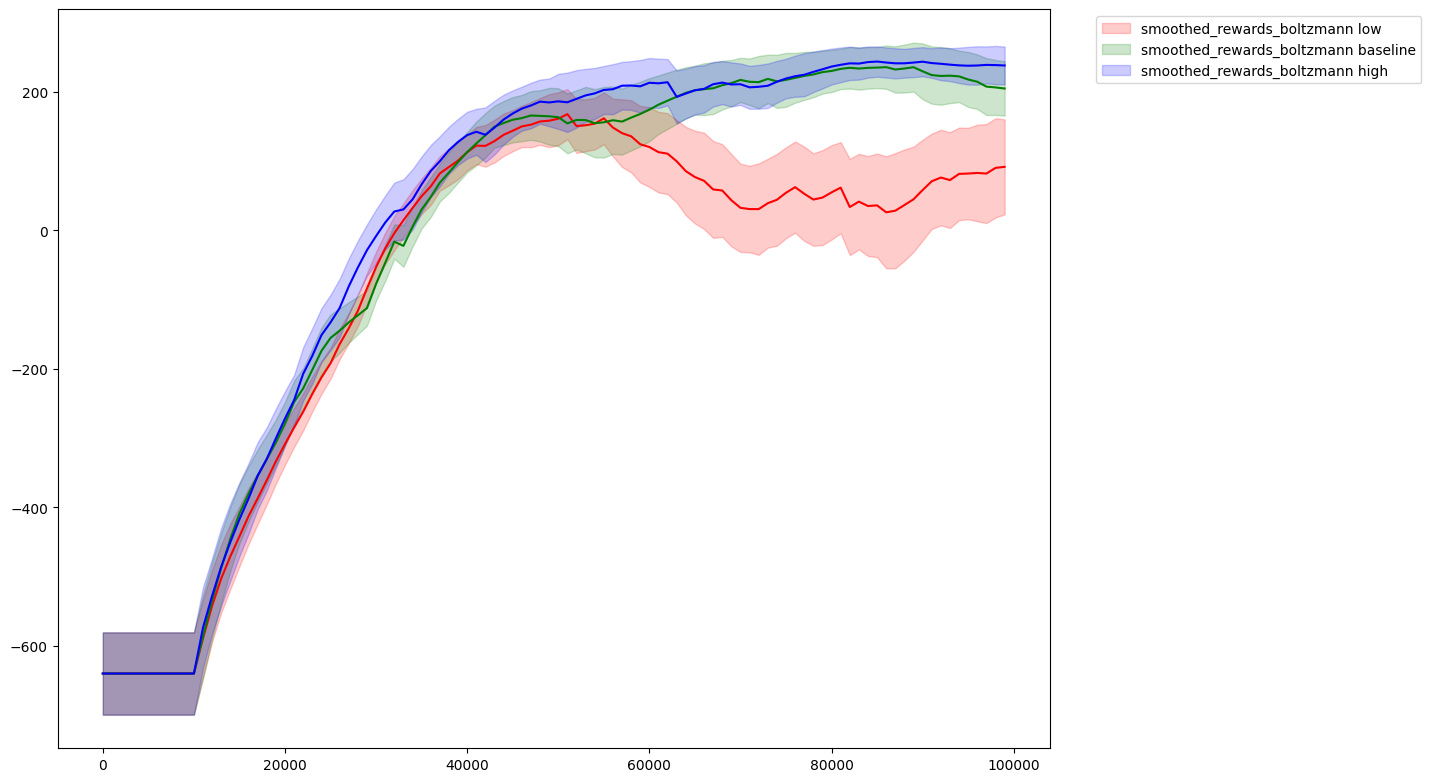

<Figure size 640x480 with 0 Axes>

In [29]:
boltzmann_low = BoltzmannDQN(args)
boltzmann_low.temperature = 0.3
boltzmann_low_mean, boltzmann_low_std = train_dqn(boltzmann_low)

boltzmann_high = BoltzmannDQN(args)
boltzmann_high.temperature = 3.0
boltzmann_high_mean, boltzmann_high_std = train_dqn(boltzmann_high)

plot_results_many(
    [boltzmann_low_mean, result_means_boltzmann_dqn, boltzmann_high_mean],
    [boltzmann_low_std, result_stds_boltzmann_dqn, boltzmann_high_std],
    ["boltzmann low", "boltzmann baseline", "boltzmann high"],
    colours_list
)

### Boltzmann Strategy with Temperature Annealing

Here we investigate the sensitivity to the starting temperature hyperparameter.

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -77.25436919280124; eval_std: 8.516672467545432
Training step: 12000
Eval mean: -169.59933978027206; 

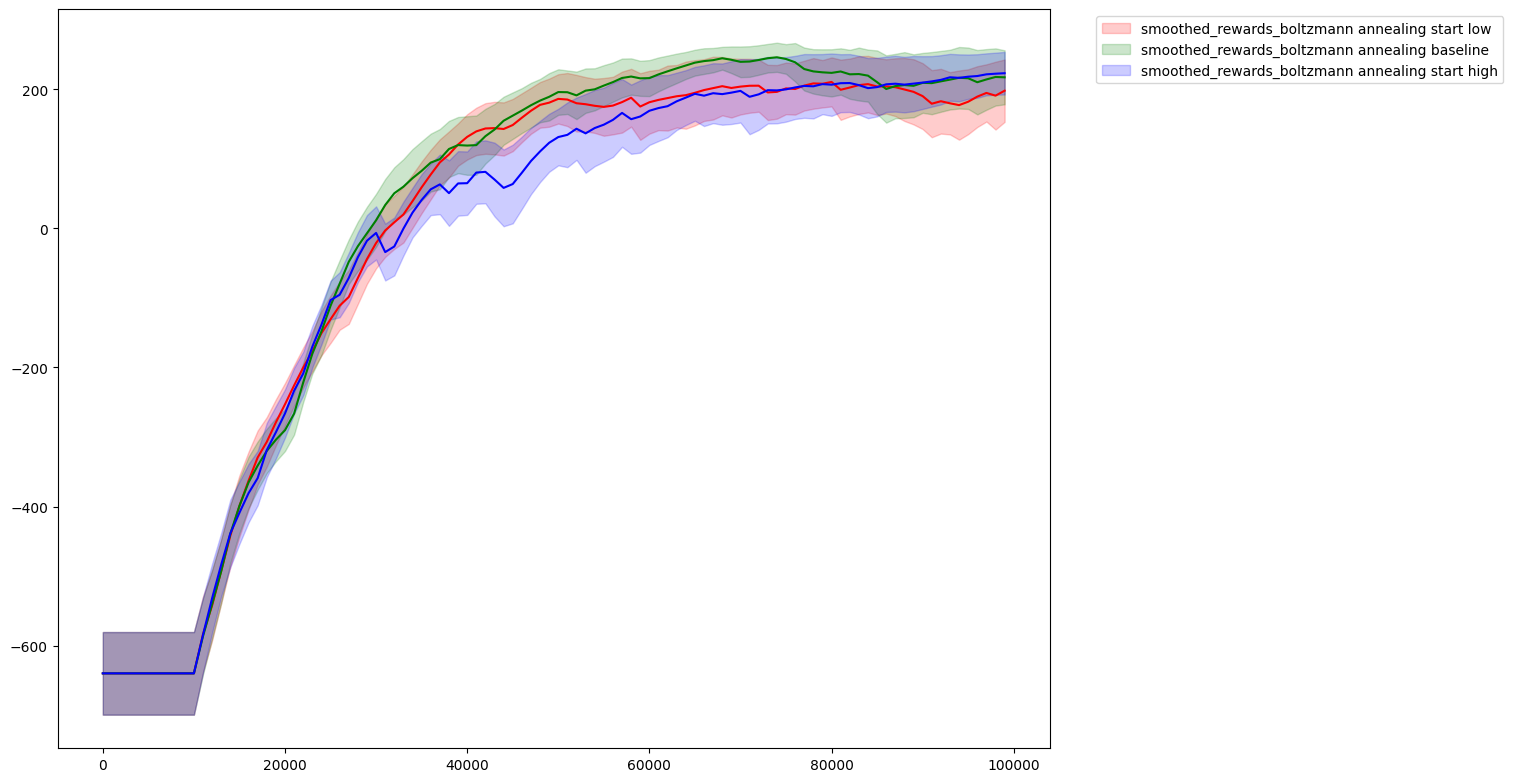

<Figure size 640x480 with 0 Axes>

In [30]:
boltzmann_annealing_start_low = BoltzmannWithTemperatureAnnealingDQN(args)
boltzmann_annealing_start_low.start_temperature = 0.05
boltzmann_annealing_start_low_mean, boltzmann_annealing_start_low_std = train_dqn(boltzmann_annealing_start_low)

boltzmann_annealing_start_high = BoltzmannWithTemperatureAnnealingDQN(args)
boltzmann_annealing_start_high.start_temperature = 0.5
boltzmann_annealing_start_high_mean, boltzmann_annealing_start_high_std = train_dqn(boltzmann_annealing_start_high)

plot_results_many(
    [boltzmann_annealing_start_low_mean, result_means_boltzmann_temp_anneal_dqn, boltzmann_annealing_start_high_mean],
    [boltzmann_annealing_start_low_std, result_stds_boltzmann_temp_anneal_dqn, boltzmann_annealing_start_high_std],
    ["boltzmann annealing start low", "boltzmann annealing baseline", "boltzmann annealing start high"],
    colours_list
)

Here we investigate the sensitivity to the final temperature hyperparameter.

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -56.98282360208151; eval_std: 31.340946326088613
Training step: 12000
Eval mean: -69.04568979276041; 

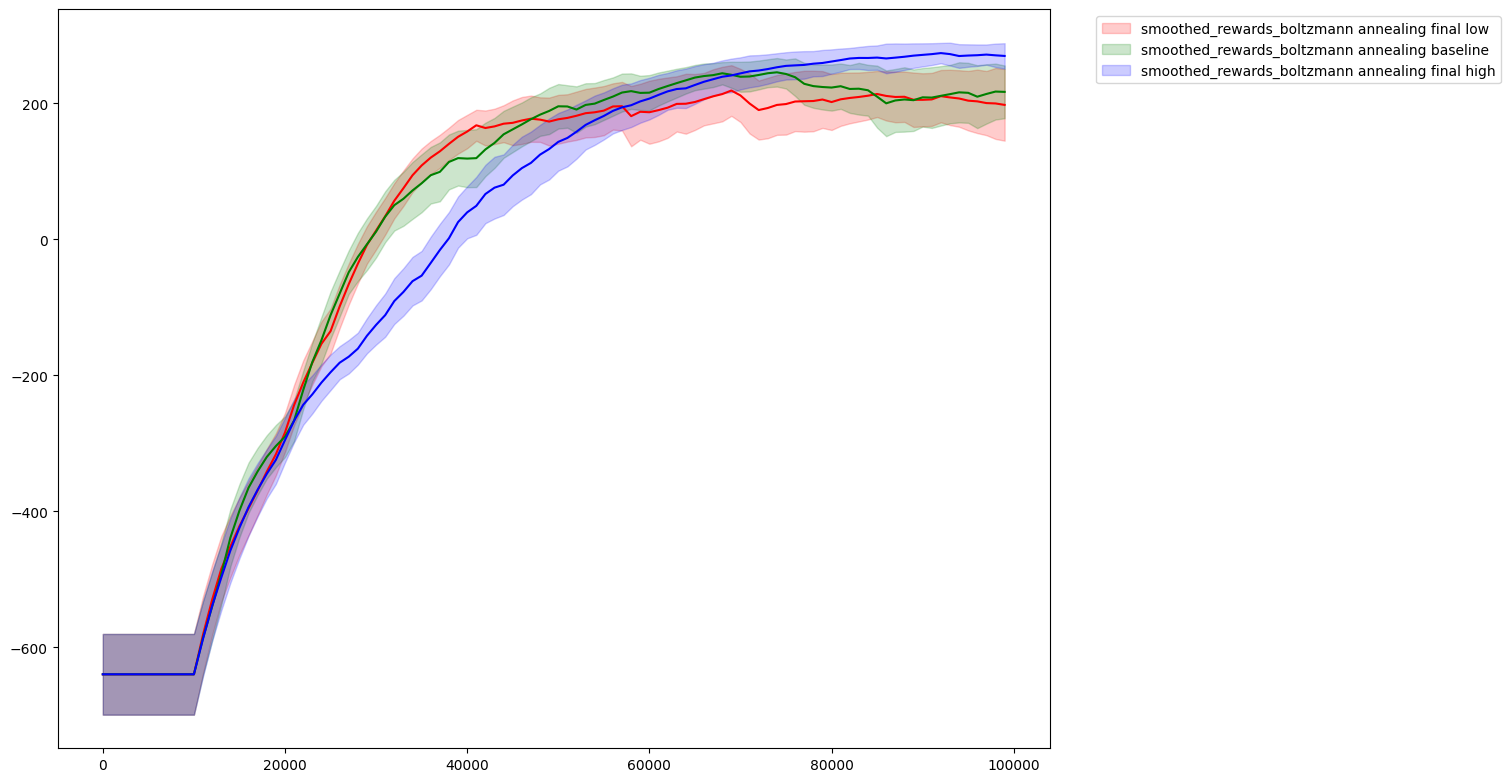

<Figure size 640x480 with 0 Axes>

In [31]:
boltzmann_annealing_final_low = BoltzmannWithTemperatureAnnealingDQN(args)
boltzmann_annealing_final_low.final_temperature = 1
boltzmann_annealing_final_low_mean, boltzmann_annealing_final_low_std = train_dqn(boltzmann_annealing_final_low)

boltzmann_annealing_final_high = BoltzmannWithTemperatureAnnealingDQN(args)
boltzmann_annealing_final_high.final_temperature = 6
boltzmann_annealing_final_high_mean, boltzmann_annealing_final_high_std = train_dqn(boltzmann_annealing_final_high)

plot_results_many(
    [boltzmann_annealing_final_low_mean, result_means_boltzmann_temp_anneal_dqn, boltzmann_annealing_final_high_mean],
    [boltzmann_annealing_final_low_std, result_stds_boltzmann_temp_anneal_dqn, boltzmann_annealing_final_high_std],
    ["boltzmann annealing final low", "boltzmann annealing baseline", "boltzmann annealing final high"],
    colours_list
)

### Max-Boltzmann Strategy

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -68.83774859134247; eval_std: 8.528929107171335
Training step: 12000
Eval mean: -61.580517288875434; 

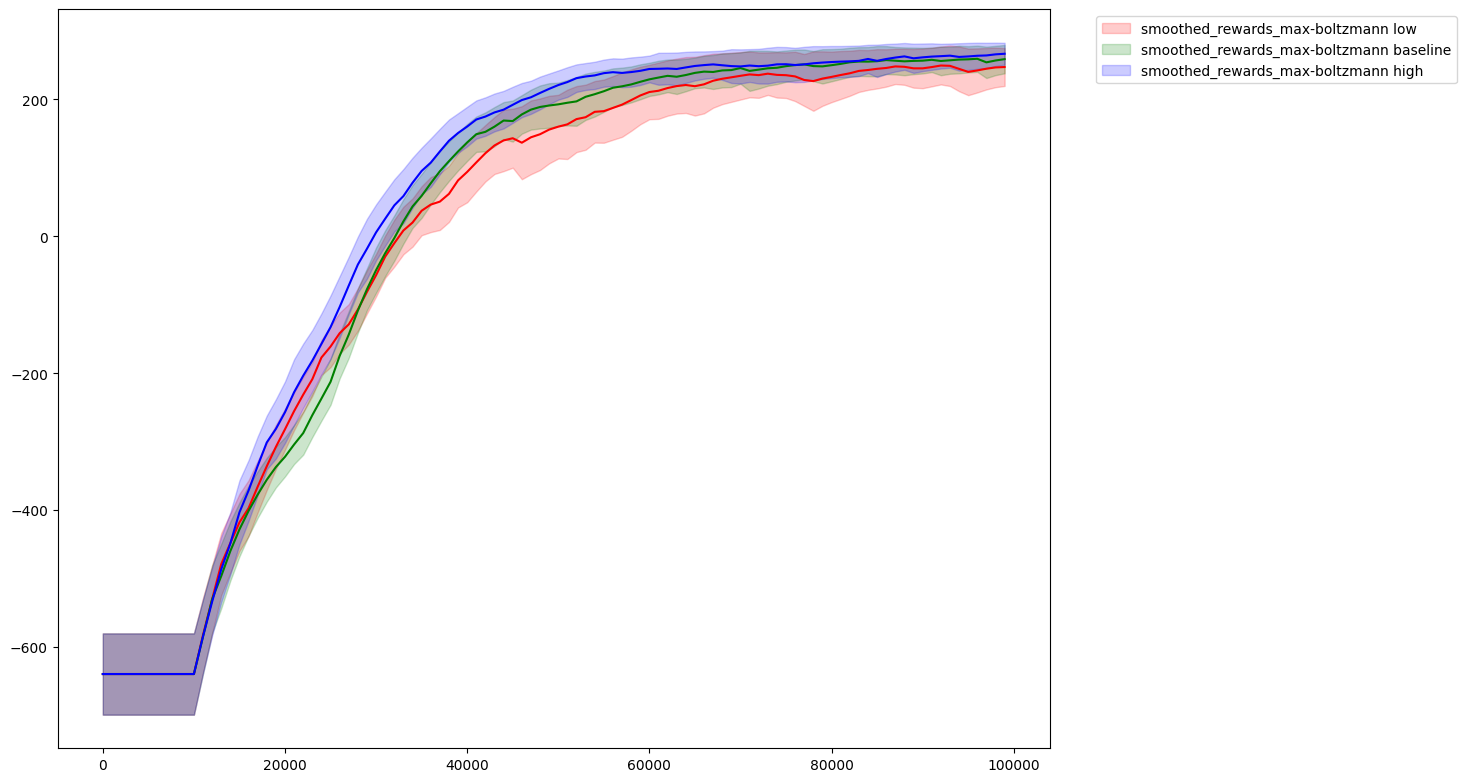

<Figure size 640x480 with 0 Axes>

In [32]:
max_boltzmann_low = MaxBoltzmannDQN(args)
max_boltzmann_low.temperature = 0.03
max_boltzmann_low_mean, max_boltzmann_low_std = train_dqn(max_boltzmann_low)

max_boltzmann_high = MaxBoltzmannDQN(args)
max_boltzmann_high.temperature = 0.3
max_boltzmann_high_mean, max_boltzmann_high_std = train_dqn(max_boltzmann_high)

plot_results_many(
    [max_boltzmann_low_mean, result_means_max_boltzmann_dqn, max_boltzmann_high_mean],
    [max_boltzmann_low_std, result_stds_max_boltzmann_dqn, max_boltzmann_high_std],
    ["max-boltzmann low", "max-boltzmann baseline", "max-boltzmann high"],
    colours_list
)

###  Max-Boltzmann Strategy with Temperature Annealing

Here we investigate the sensitivity to the starting temperature hyperparameter.

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -79.45787559771382; eval_std: 8.777674614291213
Training step: 12000
Eval mean: -55.736891778155325; 

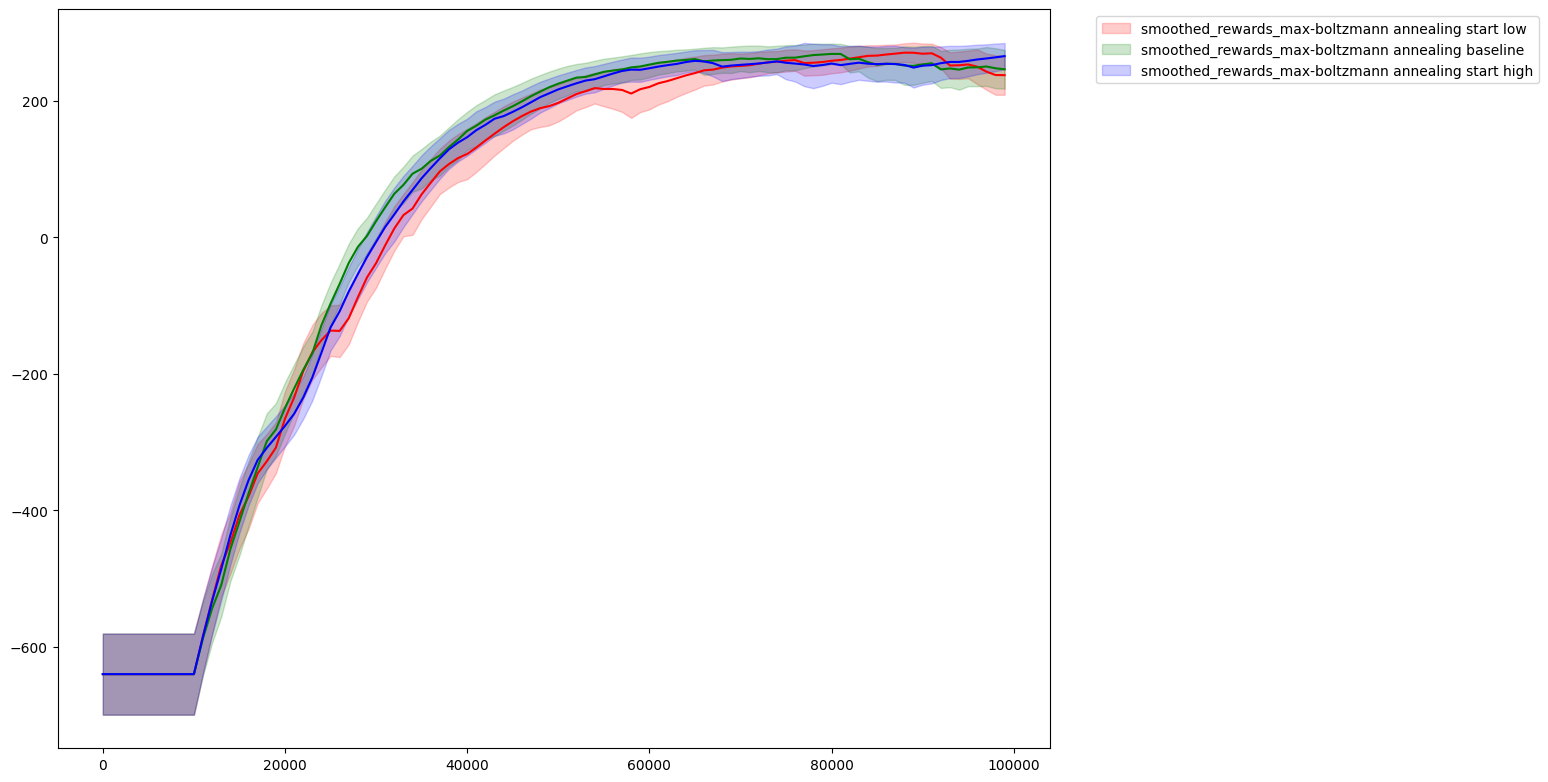

<Figure size 640x480 with 0 Axes>

In [33]:
max_boltzmann_annealing_start_low = MaxBoltzmannWithTemperatureAnnealingDQN(args)
max_boltzmann_annealing_start_low.start_temperature = 0.01
max_boltzmann_annealing_start_low_mean, max_boltzmann_annealing_start_low_std = train_dqn(max_boltzmann_annealing_start_low)

max_boltzmann_annealing_start_high = MaxBoltzmannWithTemperatureAnnealingDQN(args)
max_boltzmann_annealing_start_high.start_temperature = 0.1
max_boltzmann_annealing_start_high_mean, max_boltzmann_annealing_start_high_std = train_dqn(max_boltzmann_annealing_start_high)

plot_results_many(
    [max_boltzmann_annealing_start_low_mean, result_means_max_boltzmann_temp_anneal_dqn, max_boltzmann_annealing_start_high_mean],
    [max_boltzmann_annealing_start_low_std, result_stds_max_boltzmann_temp_anneal_dqn, max_boltzmann_annealing_start_high_std],
    ["max-boltzmann annealing start low", "max-boltzmann annealing baseline", "max-boltzmann annealing start high"],
    colours_list
)

Here we investigate the sensitivity to the final temperature hyperparameter.

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -64.36032532706598; eval_std: 8.560603765250024
Training step: 12000
Eval mean: -59.23653195558592; e

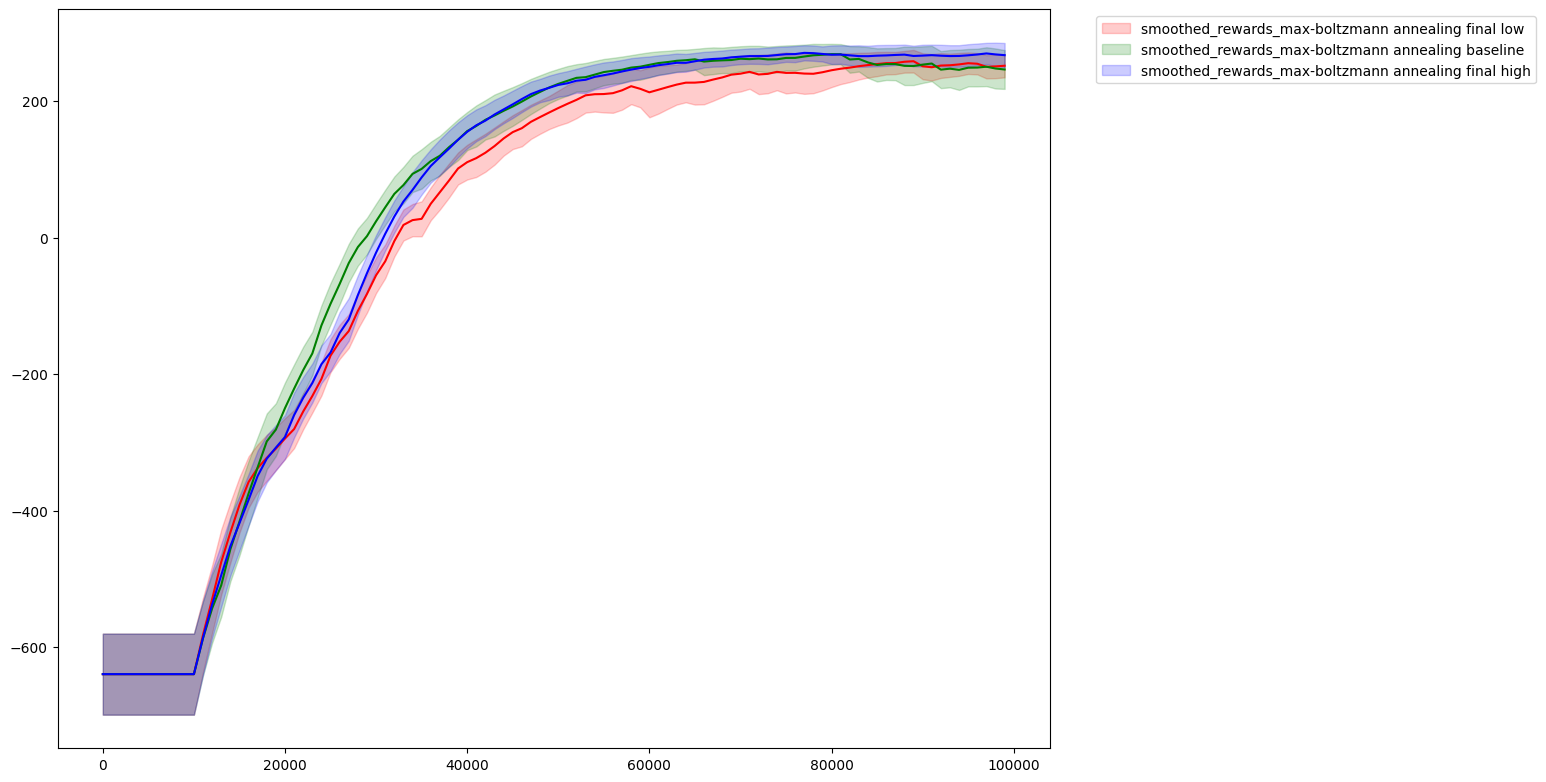

<Figure size 640x480 with 0 Axes>

In [34]:
max_boltzmann_annealing_final_low = MaxBoltzmannWithTemperatureAnnealingDQN(args)
max_boltzmann_annealing_final_low.final_temperature = 0.15
max_boltzmann_annealing_final_low_mean, max_boltzmann_annealing_final_low_std = train_dqn(max_boltzmann_annealing_final_low)

max_boltzmann_annealing_final_high = MaxBoltzmannWithTemperatureAnnealingDQN(args)
max_boltzmann_annealing_final_high.final_temperature = 0.6
max_boltzmann_annealing_final_high_mean, max_boltzmann_annealing_final_high_std = train_dqn(max_boltzmann_annealing_final_high)

plot_results_many(
    [max_boltzmann_annealing_final_low_mean, result_means_max_boltzmann_temp_anneal_dqn, max_boltzmann_annealing_final_high_mean],
    [max_boltzmann_annealing_final_low_std, result_stds_max_boltzmann_temp_anneal_dqn, max_boltzmann_annealing_final_high_std],
    ["max-boltzmann annealing final low", "max-boltzmann annealing baseline", "max-boltzmann annealing final high"],
    colours_list
)

### Combination of Epsilon-Greedy with Epsilon Annealing and Boltzmann Strategy


Here we investigate the sensitivity to epsilon.

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -100.07433981276098; eval_std: 8.905933736977026
Training step: 12000
Eval mean: -111.32235719940239;

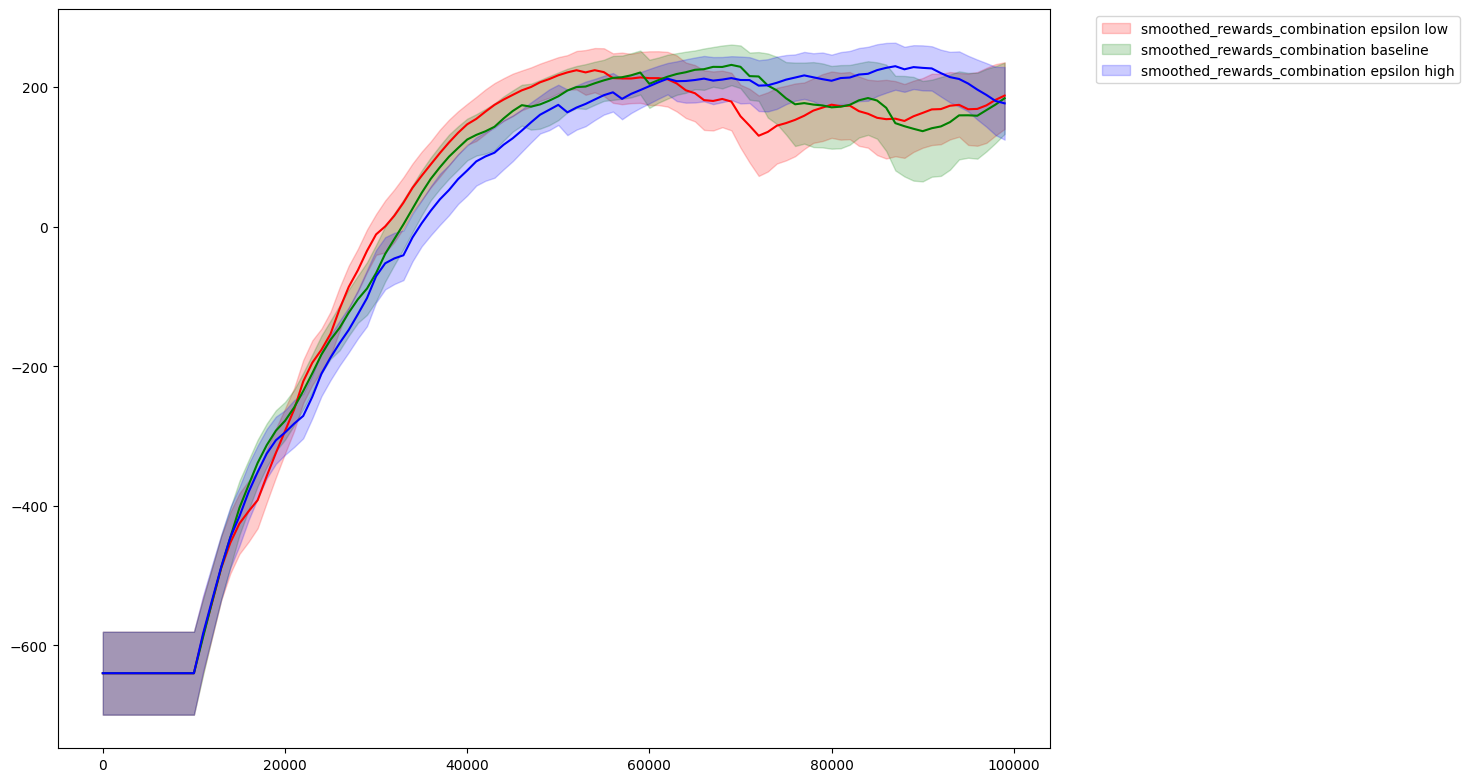

<Figure size 640x480 with 0 Axes>

In [19]:
epsilon_half_low = EpsilonGreedyWithAnnealingDQN(first_half_training_args)
epsilon_half_low.final_epsilon = 0.05
boltzmann_half_low = BoltzmannDQN(second_half_training_args)
epsilon_half_low_mean, epsilon_half_low_std = train_two_halfs_dqn(epsilon_half_low, boltzmann_half_low)

epsilon_half_high = EpsilonGreedyWithAnnealingDQN(first_half_training_args)
epsilon_half_high.final_epsilon = 0.2
boltzmann_half_high = BoltzmannDQN(second_half_training_args)
epsilon_half_high_mean, epsilon_half_high_std = train_two_halfs_dqn(epsilon_half_high, boltzmann_half_high)

plot_results_many(
    [epsilon_half_low_mean, result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, epsilon_half_high_mean],
    [epsilon_half_low_std, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, epsilon_half_high_std],
    ["combination epsilon low", "combination baseline", "combination epsilon high"],
    colours_list
)

Here we investigate the sensitivity to temperature.

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -125.62323367748047; eval_std: 9.1603644908525
Training step: 12000
Eval mean: -80.06262885753317; ev

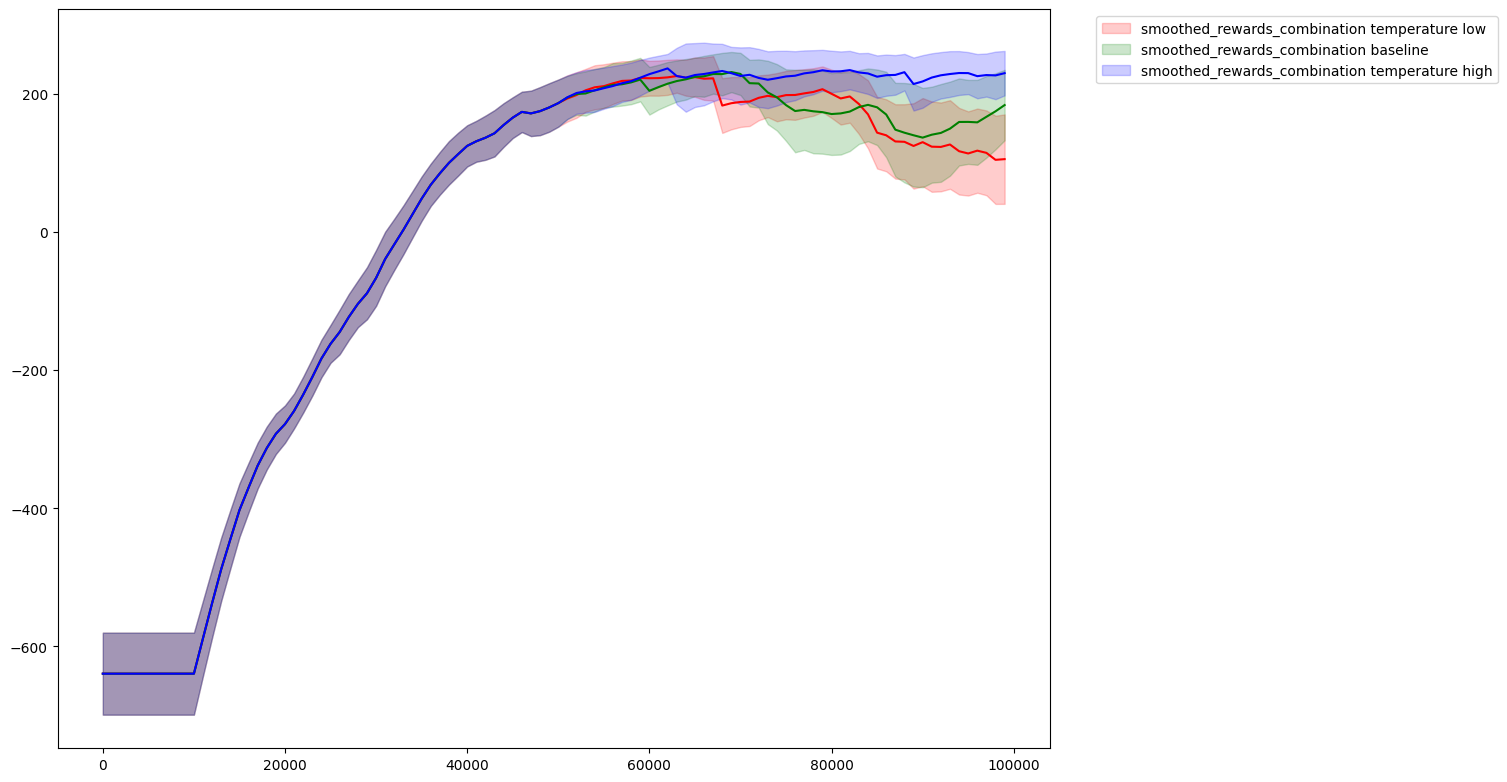

<Figure size 640x480 with 0 Axes>

In [20]:
epsilon_half_low = EpsilonGreedyWithAnnealingDQN(first_half_training_args)
boltzmann_half_low = BoltzmannDQN(second_half_training_args)
boltzmann_half_low.temperature = 0.3
boltzmann_half_low_mean, boltzmann_half_low_std = train_two_halfs_dqn(epsilon_half_low, boltzmann_half_low)

epsilon_half_high = EpsilonGreedyWithAnnealingDQN(first_half_training_args)
boltzmann_half_high = BoltzmannDQN(second_half_training_args)
boltzmann_half_high.temperature = 3
boltzmann_half_high_mean, boltzmann_half_high_std = train_two_halfs_dqn(epsilon_half_high, boltzmann_half_high)

plot_results_many(
    [boltzmann_half_low_mean, result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, boltzmann_half_high_mean],
    [boltzmann_half_low_std, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, boltzmann_half_high_std],
    ["combination temperature low", "combination baseline", "combination temperature high"],
    colours_list
)

## Comparing Methods

## Epsilon-Greedy With and Without Annealing

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -578.48360418 -523.97331192 -476.18750206 -416.85517308
 -385.08433388 -356.99213996 -333.24198932 -313.85949653 -300.08201089
 -283.05373194 -266.06512765 -252.2917149  -238.26951702 -232.19703155
 -214.6174865  -195.4976923  -181.0750661  -171.90130543 -166.63603993
 -155.3302468  -146.80501925 -133.30874115 -111.8883182  -103.06502401
  -94.85872224  -95.35702226  -98.79848187  -85.15331174  -82.41087534
  -76.4486041   -71.47559308  -68.57756897  -62.96139462  -46.43440863
  -24.50906035   -4.14956346    8.19814401   22.46181738   38.37358816
   46.68945752   49.4178632    55.42455797   57.38270173   66.13494767
   80.73983737   92.98401355  105.81405665  108.38896481  114.70537914
  126.5687755   138.17567731  150.1014371   157.61444532  165.38269068
  171.99103178  179.25706598  185.10754852  189.40420367  189.23224073
  187.

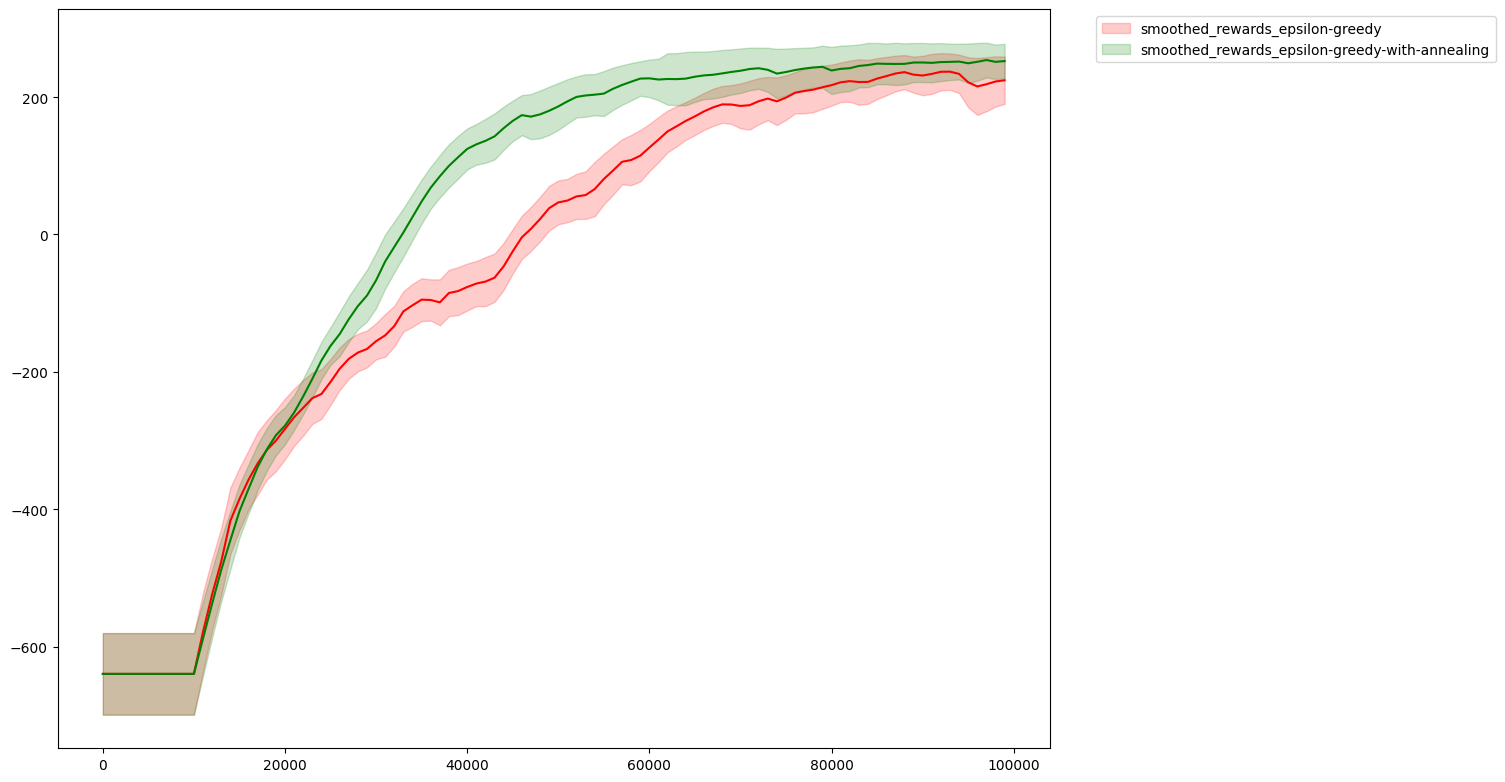

<Figure size 640x480 with 0 Axes>

In [31]:
result_means_list = [result_means_epsilon_greedy_dqn, result_means_epsilon_greedy_with_annealing_dqn]
result_stds_list = [result_stds_epsilon_greedy_dqn, result_stds_epsilon_greedy_with_annealing_dqn]
names_list = ["epsilon-greedy", "epsilon-greedy-with-annealing"]
colours_list = ["red", "green"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)

## Epsilon-Greedy with Annealing and MaxBoltzmann

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -588.28363634 -537.4615356  -488.29984624 -445.17147491
 -402.92574734 -370.29076105 -338.46447731 -313.01380621 -292.36051315
 -278.30095607 -259.21987145 -235.59525981 -210.17603659 -183.38661159
 -162.13269371 -145.01173931 -123.3229226  -104.2393829   -88.86551921
  -66.66958397  -39.18236799  -18.02035677    3.02965251   25.52393779
   48.08033437   68.20504019   84.76166549   99.96863542  112.46789231
  124.55762183  131.20040895  136.33186494  142.79911381  154.74137179
  165.3999966   173.77674775  171.60118326  174.86486074  180.15721378
  186.44942462  193.76935313  200.28605185  202.40510286  203.57570227
  205.12418828  212.06737043  217.6188865   222.42629948  226.99652852
  227.34331201  225.61617176  226.40326666  226.21301573  226.93061025
  229.72651569  231.61423813  232.5572017   234.53807227  236.64787357
  238.

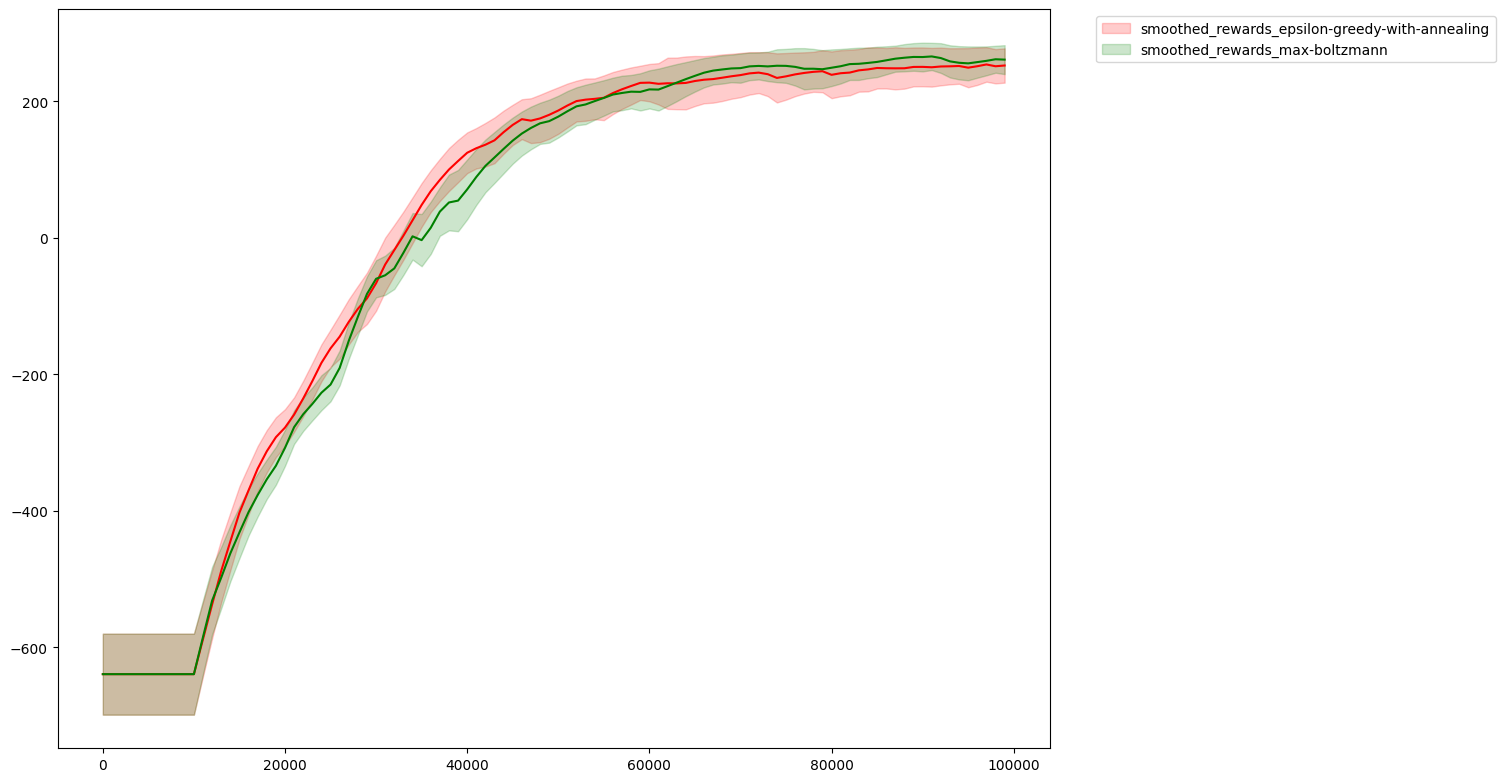

<Figure size 640x480 with 0 Axes>

In [32]:
result_means_list = [result_means_epsilon_greedy_with_annealing_dqn, result_means_max_boltzmann_dqn]
result_stds_list = [result_stds_epsilon_greedy_with_annealing_dqn, result_stds_max_boltzmann_dqn]
names_list = ["epsilon-greedy-with-annealing", "max-boltzmann", "max-boltzmann-with-annealing"]
colours_list = ["red", "green"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)

## Boltzmann and Max-Boltzmann (both with temperature annealing)

[-6.39690348e+02 -6.39690348e+02 -6.39690348e+02 -6.39690348e+02
 -6.39690348e+02 -6.39690348e+02 -6.39690348e+02 -6.39690348e+02
 -6.39690348e+02 -6.39690348e+02 -6.39690348e+02 -5.85976819e+02
 -5.38096620e+02 -4.85203217e+02 -4.17289175e+02 -3.78616734e+02
 -3.41144558e+02 -3.05159279e+02 -2.66795790e+02 -2.38151222e+02
 -2.19977951e+02 -2.01104767e+02 -1.61531306e+02 -1.25120448e+02
 -8.80226780e+01 -5.78295444e+01 -2.75339089e+01  1.33978427e-02
  2.67349499e+01  4.76624414e+01  6.42001573e+01  8.36389379e+01
  9.97665825e+01  1.01591348e+02  1.01539005e+02  1.11103238e+02
  1.14732583e+02  1.23676234e+02  1.34047157e+02  1.43860566e+02
  1.53496197e+02  1.61388899e+02  1.70605407e+02  1.77694317e+02
  1.83025687e+02  1.87369097e+02  1.87608802e+02  1.83350062e+02
  1.85431514e+02  1.78762768e+02  1.63400010e+02  1.71614078e+02
  1.71421747e+02  1.72458699e+02  1.80793030e+02  1.79589417e+02
  1.80428924e+02  1.59477826e+02  1.60933797e+02  1.63493301e+02
  1.70552340e+02  1.71074

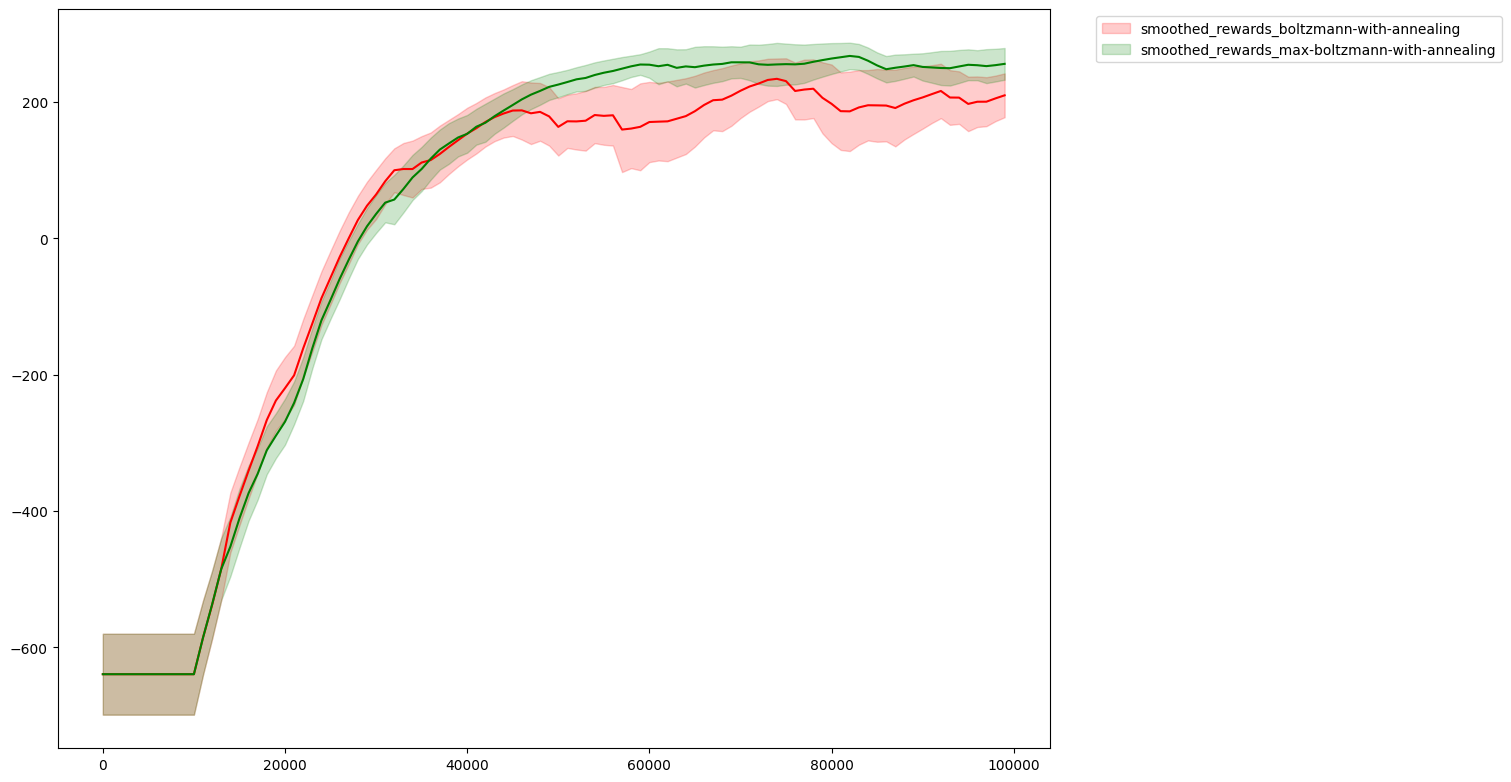

<Figure size 640x480 with 0 Axes>

In [33]:
result_means_list = [result_means_boltzmann_temp_anneal_dqn, result_means_max_boltzmann_temp_anneal_dqn]
result_stds_list = [result_stds_boltzmann_temp_anneal_dqn, result_stds_max_boltzmann_temp_anneal_dqn]
names_list = ["boltzmann-with-annealing", "max-boltzmann-with-annealing"]
colours_list = ["red", "green"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)

## Annealing Epsilon-Greedy, Boltzmann and Hybrid

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -588.28363634 -537.4615356  -488.29984624 -445.17147491
 -402.92574734 -370.29076105 -338.46447731 -313.01380621 -292.36051315
 -278.30095607 -259.21987145 -235.59525981 -210.17603659 -183.38661159
 -162.13269371 -145.01173931 -123.3229226  -104.2393829   -88.86551921
  -66.66958397  -39.18236799  -18.02035677    3.02965251   25.52393779
   48.08033437   68.20504019   84.76166549   99.96863542  112.46789231
  124.55762183  131.20040895  136.33186494  142.79911381  154.74137179
  165.3999966   173.77674775  171.60118326  174.86486074  180.15721378
  186.44942462  193.76935313  200.28605185  202.40510286  203.57570227
  205.12418828  212.06737043  217.6188865   222.42629948  226.99652852
  227.34331201  225.61617176  226.40326666  226.21301573  226.93061025
  229.72651569  231.61423813  232.5572017   234.53807227  236.64787357
  238.

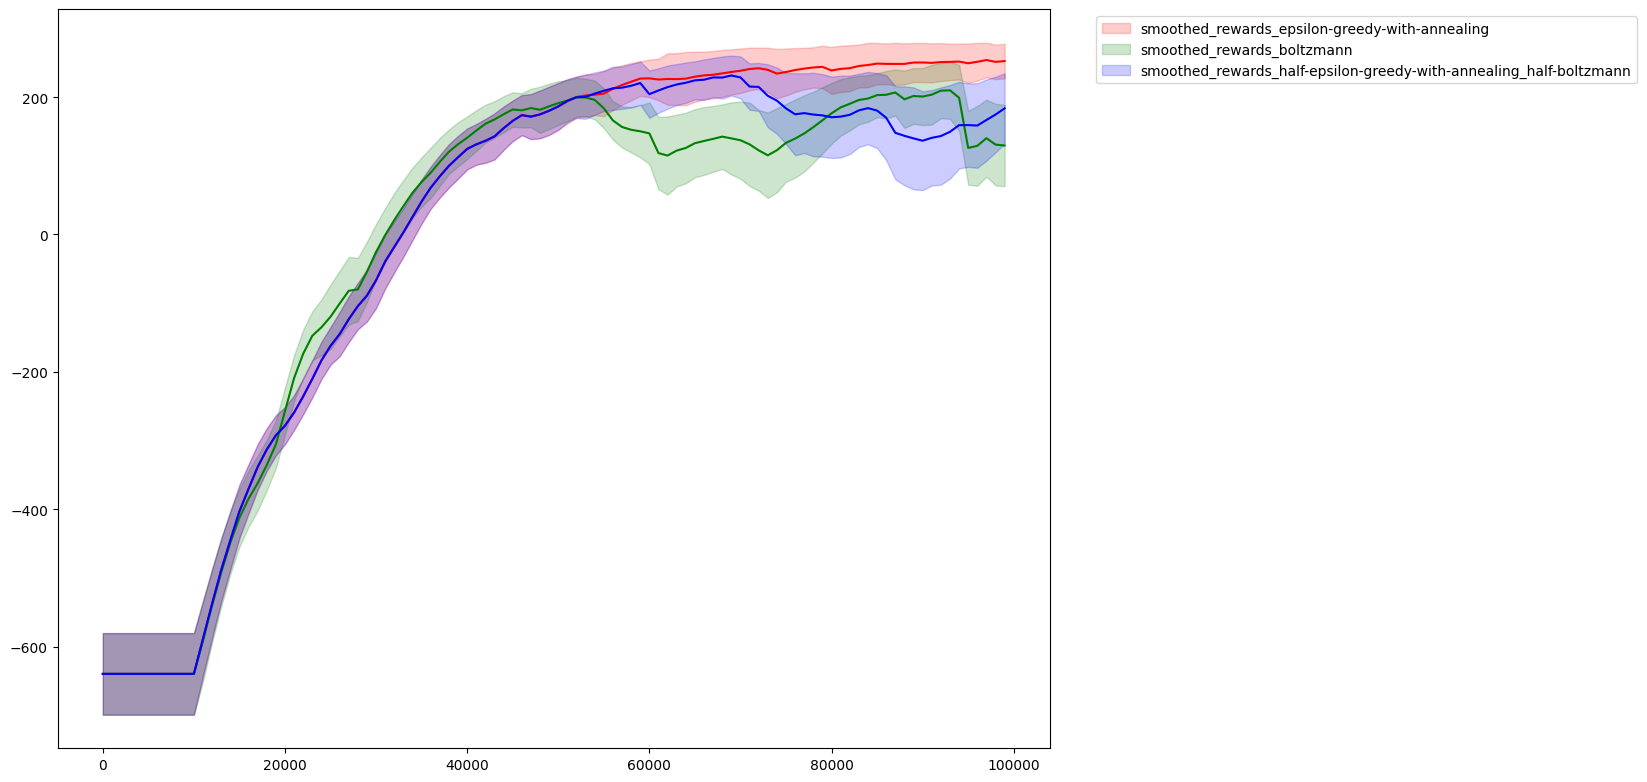

<Figure size 640x480 with 0 Axes>

In [35]:
result_means_list = [result_means_epsilon_greedy_with_annealing_dqn, result_means_boltzmann_dqn, result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
result_stds_list = [result_stds_epsilon_greedy_with_annealing_dqn, result_stds_boltzmann_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
names_list = ["epsilon-greedy-with-annealing", "boltzmann", "half-epsilon-greedy-with-annealing_half-boltzmann"]
colours_list = ["red", "green", "blue"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)